# 03 – CPM Multi-Wavelength

This tutorial demonstrates polychromatic CPM reconstruction using a multi-wavelength dataset measured from a mouse brain sample. It shows how to handle spectral density weighting and run a multi-wavelength engine.

**What you'll learn:**

- How to set up a polychromatic (`nlambda > 1`) reconstruction
- How to use spectral density weighting
- How to interpret multi-wavelength reconstruction results

!!! note "Dataset"
    The dataset (`Brain_smoothBeam_poly_bin8.hdf5`, ~500 MB) is downloaded automatically into the `example_data/` folder at the project root the first time you run the notebook. If the file already exists it is not re-downloaded.

!!! tip "Prerequisites"
    Complete [01 – CPM Simulation](tutorial_CPM_sim.ipynb) before this tutorial.

In [20]:
# %matplotlib notebook
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import h5py

In [21]:
# import the fracPy module
import PtyLab
from PtyLab import ExperimentalData
from PtyLab import Reconstruction
from PtyLab import Monitor
from PtyLab import Params
from PtyLab import Engines

In [22]:
from PtyLab.utils.visualisation import hsvplot, hsvmodeplot, absplot, absmodeplot

In [23]:
from PtyLab.io import getExampleDataFolder
import urllib.request

fileName = "Brain_smoothBeam_poly_bin8.hdf5"
filePath = getExampleDataFolder() / fileName

if not filePath.exists():
    print(f"Downloading {fileName} (~500 MB)...")
    urllib.request.urlretrieve(
        "https://ndownloader.figshare.com/files/33950357",
        filePath,
    )
    print("Download complete.")
else:
    print(f"{fileName} found, skipping download.")

Brain_smoothBeam_poly_bin8.hdf5 found, skipping download.


In [24]:
from PtyLab.utils.utils import posit
# Step 2: Initialize the ExperimentalData class

# Initialize the ExperimentalData using the filePath, and choose the operation Mode (default is 'CPM')
experimentalData = ExperimentalData(filePath, operationMode="CPM")
backgroundOffset = 10
experimentalData.entrancePupilDiameter = 0.2e-3

experimentalData.ptychogram = posit(experimentalData.ptychogram - backgroundOffset)
# show measured ptychogram in log scale. Need to close the window to continue
# experimentalData.showPtychogram()

Found encoder with shape (890, 2)


In [25]:
# Set monitor properties
monitor = Monitor()
monitor.figureUpdateFrequency = 1
monitor.objectPlot = "angle"  # complex abs angle
monitor.verboseLevel = "low"  # high: plot two figures, low: plot only one figure
monitor.probeZoom = 1  # control probe plot FoV
monitor.objectZoom = 1  # control object plot FoV
monitor.objectPlotContrast = 8
monitor.probePlotContrast = 1

/Users/shantanukodgirwar/Projects/PtyLab.py/PtyLab/Monitor/Monitor.py:178: UserWarning: For faster update of the reconstruction plot, set `monitor.figureUpdateFrequency = 5` or higher.
  warnings.warn(


In [26]:
params = Params()
params.gpuSwitch = False  # set to True to use GPU (if available)
params.positionOrder = "random"  # 'sequential' or 'random'
params.propagatorType = (
    "Fraunhofer"  # Fraunhofer Fresnel ASP scaledASP polychromeASP scaledPolychromeASP
)
params.probePowerCorrectionSwitch = False
params.modulusEnforcedProbeSwitch = True
params.comStabilizationSwitch = True
params.orthogonalizationSwitch = True
params.orthogonalizationFrequency = 5
params.intensityConstraint = "standard"  # standard fluctuation exponential poission
params.couplingSwitch = True
params.couplingAleph = 0.5

INFO:GPU:cupy is unavailable, switching to CPU


INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ


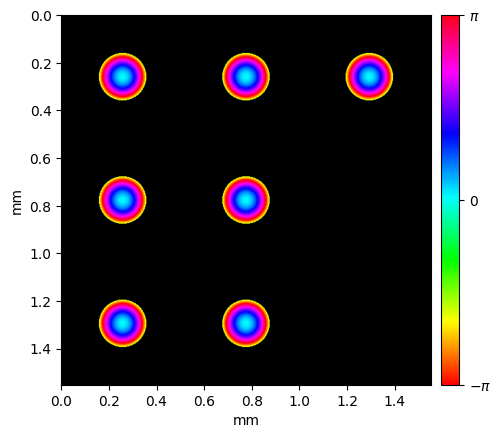

In [27]:
# now, all our experimental data is loaded into experimental_data and we don't have to worry about it anymore.
# now create an object to hold everything we're eventually interested in
reconstruction = Reconstruction(experimentalData, params)
reconstruction.No = 2**10
reconstruction.nlambda = len(reconstruction.spectralDensity)

# initialize probe and object and related params
reconstruction.initialProbe = "circ"
reconstruction.initialObject = "ones"
reconstruction.initializeObjectProbe()

# # customize initial probe quadratic phase
reconstruction.probe = reconstruction.probe * np.exp(
    1.0j
    * 2
    * np.pi
    / reconstruction.wavelength
    * (reconstruction.Xp**2 + reconstruction.Yp**2)
    / (1 * 2e-2)
)

hsvmodeplot(
    np.squeeze(reconstruction.probe), pixelSize=reconstruction.dxp, axisUnit="mm"
)

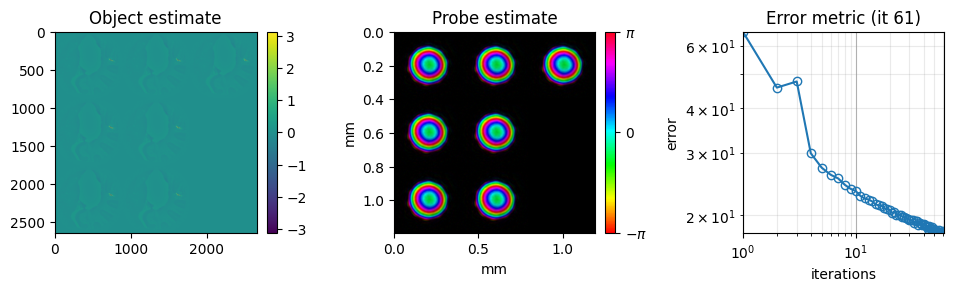

multiPIE:  61%|██████    | 61/100 [08:46<05:36,  8.63s/it]


KeyboardInterrupt: 

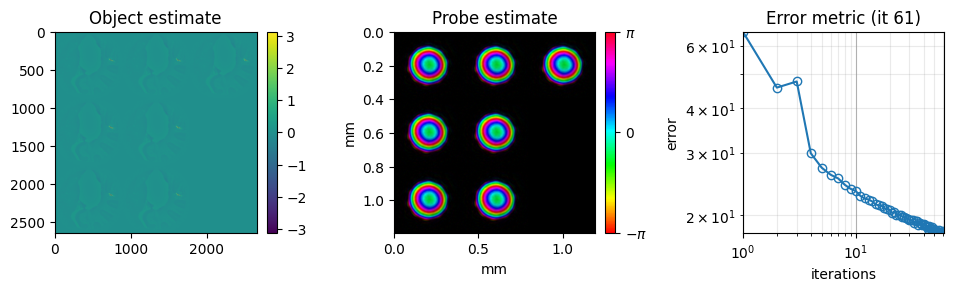

In [28]:
# Run the reconstruction
## choose engine
# mPIE
multiPIE = Engines.multiPIE(reconstruction, experimentalData, params, monitor)
multiPIE.numIterations = 100
multiPIE.betaProbe = 0.25
multiPIE.betaObject = 0.25
multiPIE.reconstruct()

In [ ]:
# now save the data
# reconstruction.saveResults('reconstruction.hdf5')